In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("../data/raw/train.csv")
df["LogSalePrice"] = np.log(df["SalePrice"])

X = df[["OverallQual", "GrLivArea"]]
y = df["LogSalePrice"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

## Stage 5 — Regression Diagnostics and Assumptions

In this stage, regression diagnostics are used to evaluate whether the assumptions of linear regression are reasonably satisfied.

The goal is not to fix the model, but to understand its limitations and assess how reliable the results are.

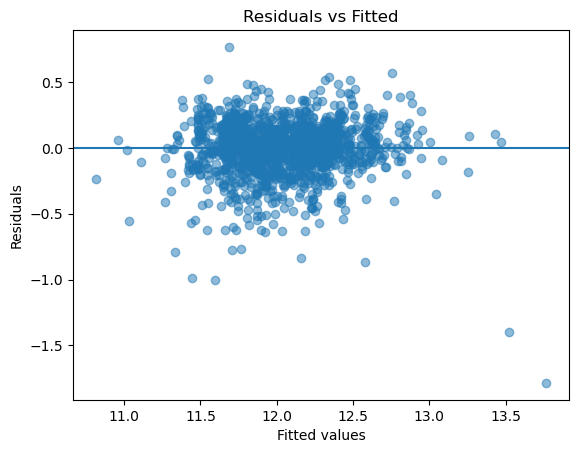

In [2]:

fitted_vals = model.fittedvalues
residuals = model.resid

# Residuals vs Fitted plot
plt.scatter(fitted_vals, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

### Residuals vs Fitted

The residuals versus fitted values plot is used to check the assumptions of linear regression.

In this plot, the residuals are scattered around zero without a clear pattern.
This suggests that the relationship between the predictors and the target variable is approximately linear.

The spread of residuals appears relatively constant across the range of fitted values.
This indicates that there is no strong evidence of heteroscedasticity.

Overall, this plot suggests that the linear regression model provides a reasonable fit to the data.S

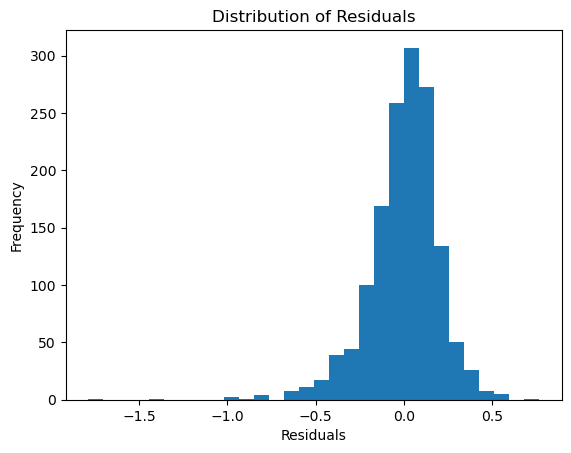

In [3]:
# Histogram of residuals
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

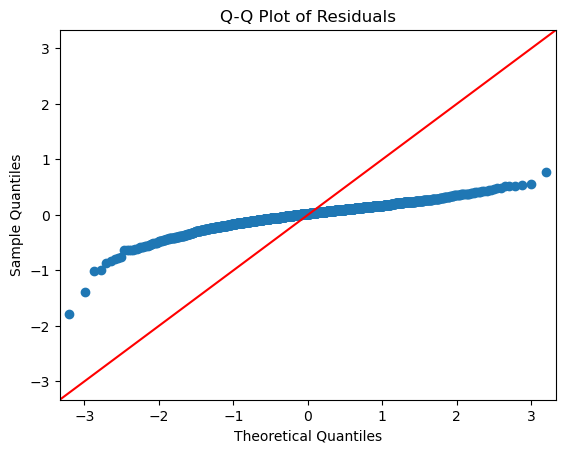

In [4]:
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

### Normality of Residuals

The normality of residuals is examined using a histogram and a Q–Q plot.

The histogram of residuals shows a distribution that is roughly bell-shaped, but not perfectly symmetric.
Most residuals are concentrated around zero, which is expected in a linear regression model.

The Q–Q plot shows noticeable deviations from the reference line, especially in the lower tail.
This indicates that the residuals are not perfectly normally distributed and exhibit some skewness.

Such deviations are common in large real-world datasets.
Overall, while the normality assumption is not fully satisfied, the residuals are sufficiently close to normal for the purposes of this analysis.